In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Ti


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [4]:
train_dataset = datasets.ImageFolder(
    "../data1/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "../data1/val",
    transform=transform
)

In [5]:
print(train_dataset.classes)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [6]:
from collections import Counter

print(Counter(train_dataset.targets))
print(Counter(val_dataset.targets))

Counter({0: 800, 1: 800, 2: 121})
Counter({0: 200, 1: 200, 2: 31})


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [9]:
model = models.densenet121(pretrained=True)

c:\Users\desig\Desktop\Summer research\CV\Potatoplant\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\desig\Desktop\Summer research\CV\Potatoplant\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
model.classifier = nn.Linear(
    model.classifier.in_features,
    3
)

In [11]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [14]:
model.train()

running_loss = 0.0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

print("Training completed!")
print("Loss:", running_loss)

Training completed!
Loss: 28.145152375102043


In [15]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 92.58%


In [16]:
num_epochs = 5

In [17]:
train_losses = []
val_accuracies = []

In [18]:
for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

Epoch 1/5
Loss: 0.2287
Validation Accuracy: 97.45%
Epoch 2/5
Loss: 0.1523
Validation Accuracy: 97.91%
Epoch 3/5
Loss: 0.1155
Validation Accuracy: 98.14%
Epoch 4/5
Loss: 0.1029
Validation Accuracy: 97.91%
Epoch 5/5
Loss: 0.0874
Validation Accuracy: 98.61%


In [ ]:
torch.save(model.state_dict(), "../models/densenet121_data1.pth")

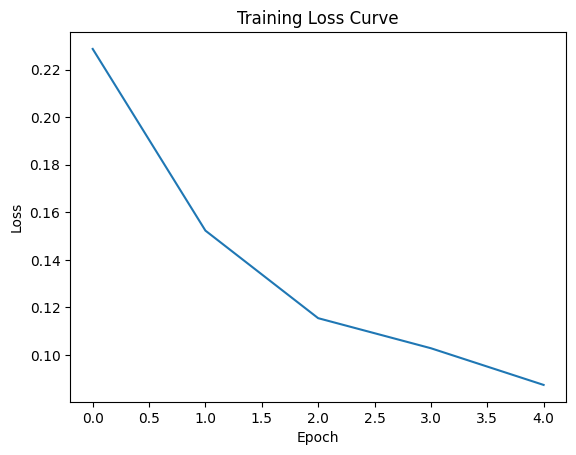

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [21]:
plt.savefig("../results/densenet_loss_data1.png")

<Figure size 640x480 with 0 Axes>

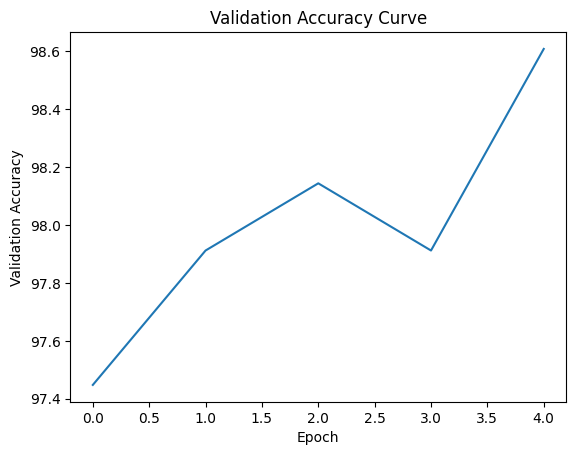

In [22]:
plt.plot(val_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy Curve")

plt.show()

In [23]:
plt.savefig("../results/densenet_acc_data1.png")

<Figure size 640x480 with 0 Axes>